In [18]:
from IPython.display import clear_output as c
!pip install torchvision opencv-python pandas
!pip install kagglehub Kaggle
!pip install scikit-learn matplotlib

c()

In [19]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")

print("Path to dataset files:", path)

100%|██████████| 786M/786M [00:10<00:00, 75.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1


In [20]:
import shutil
import os

# Assuming 'path' variable holds the downloaded dataset path from previous code.
# If not, replace with the actual path to your Kaggle dataset.

path = "/kaggle/input/"
destination = "/content"

# Check if source directory exists
if not os.path.exists(path):
  print(f"Source directory '{path}' does not exist.")
else:
    # Iterate over files in source directory
  for filename in os.listdir(path):
    source_file = os.path.join(path, filename)
    destination_file = os.path.join(destination, filename)

    # Copy the file to the destination directory
    try:
      if os.path.isdir(source_file):  # Handle subdirectories
        shutil.copytree(source_file, destination_file)
      else:
        shutil.copy2(source_file, destination_file) # copy2 preserves metadata
      print(f"Copied '{filename}' to '{destination}'")
    except Exception as e:
      print(f"Error copying '{filename}': {e}")


Error copying 'skin-cancer9-classesisic': [Errno 17] File exists: '/content/skin-cancer9-classesisic'


In [21]:
import os

# Create the output directory
output_dir = '/content/split_dataset'
os.makedirs(output_dir, exist_ok=True)


In [22]:
import os
import shutil
import random
from tqdm import tqdm

# 🟢 Original dataset location (contains original train/ and test/)
base_dir = '/content/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration'
original_train = os.path.join(base_dir, 'Train')
original_test = os.path.join(base_dir, 'Test')

# 🟢 Where you want the new splits to be saved
output_dir = '/content/split_dataset'
merged_dir = os.path.join(output_dir, 'all_data')

# Create merged directory
os.makedirs(merged_dir, exist_ok=True)

# Step 1: Merge train + test into all_data/
for folder in [original_train, original_test]:
    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue

        target_class_path = os.path.join(merged_dir, class_name)
        os.makedirs(target_class_path, exist_ok=True)

        for img_file in os.listdir(class_path):
            src = os.path.join(class_path, img_file)
            dst = os.path.join(target_class_path, img_file)
            if not os.path.exists(dst):
                shutil.copy(src, dst)

print("✅ Merged train and test into 'all_data/'")

# Step 2: Create final train, val, test folders in output_dir
splits = ['train', 'val', 'test']
split_ratios = {'train': 0.8, 'val': 0.15, 'test': 0.5}

for split in splits:
    for class_name in os.listdir(merged_dir):
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

# Step 3: Shuffle and split
for class_name in os.listdir(merged_dir):
    class_path = os.path.join(merged_dir, class_name)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * split_ratios['train'])
    val_end = train_end + int(total * split_ratios['val'])

    split_data = {
        'train': images[:train_end],
        'val': images[train_end:val_end],
        'test': images[val_end:]
    }

    for split, split_imgs in split_data.items():
        for img_name in tqdm(split_imgs, desc=f"{class_name} → {split}"):
            src = os.path.join(class_path, img_name)
            dst = os.path.join(output_dir, split, class_name, img_name)
            shutil.copy(src, dst)

print("\n✅ Final splits created in:", output_dir)


✅ Merged train and test into 'all_data/'


pigmented benign keratosis → test: 100%|██████████| 25/25 [00:00<00:00, 256.46it/s]


✅ Final splits created in: /content/split_dataset


In [23]:
import os
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Define image size
IMAGE_SIZE = 224
BATCH_SIZE = 32

# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Data augmentation and preprocessing for training
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Preprocessing only (no augmentation) for validation and test
test_val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Load datasets
data_dir = "/content/split_dataset"

train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=test_val_transforms)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=test_val_transforms)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
class_names = train_dataset.classes

In [24]:
class SkinDiseaseCNNDeeper(nn.Module):
    def __init__(self, num_classes):
        super(SkinDiseaseCNNDeeper, self).__init__()

        # Example of a deeper CNN with batch normalization
        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Fully connected block
        self.fc_block = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512 * 14 * 14, 1024),  # Adjust size based on input image
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # Flatten the output from conv layers
        x = self.fc_block(x)
        return x


In [25]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SkinDiseaseCNNDeeper(num_classes=len(class_names)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)  # L2 regularization
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)


In [26]:
import copy
import numpy as np

class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = np.Inf
        self.best_model = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience


In [39]:
import torch
from tqdm import tqdm
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

# EarlyStopping class
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.best_model = None

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_model = model.state_dict()
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

# Train the model
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs):
    early_stopper = EarlyStopping(patience=7)

    train_losses = []  # Track training loss
    val_losses = []    # Track validation loss

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        # Training loop
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Average training loss for the epoch
        train_losses.append(train_loss / len(train_loader))

        # Validation loss
        val_loss = evaluate(model, val_loader, criterion)
        val_losses.append(val_loss)

        # Learning rate scheduler
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss:.4f}")

        # Early stopping check
        if early_stopper(val_loss, model):
            print("Early stopping triggered.")
            break

    # Save the best model
    torch.save(early_stopper.best_model, 'best_skin_model.pth')

    return train_losses, val_losses

# Evaluation function (to track validation loss)
def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(dataloader)

# After training, plot the loss curves
def plot_loss_curves(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


Epoch 1: 100%|██████████| 71/71 [00:49<00:00,  1.44it/s]


Epoch 1, Train Loss: 1.2730, Val Loss: 1.1041


Epoch 2: 100%|██████████| 71/71 [00:49<00:00,  1.43it/s]


Epoch 2, Train Loss: 1.2492, Val Loss: 1.0481


Epoch 3: 100%|██████████| 71/71 [00:49<00:00,  1.44it/s]


...

Epoch 34, Train Loss: 0.9788, Val Loss: 0.8243


Epoch 35: 100%|██████████| 71/71 [00:49<00:00,  1.43it/s]


Epoch 35, Train Loss: 0.9754, Val Loss: 0.8146


Epoch 36: 100%|██████████| 71/71 [00:48<00:00,  1.46it/s]


Epoch 36, Train Loss: 0.9543, Val Loss: 0.8135
Early stopping triggered.


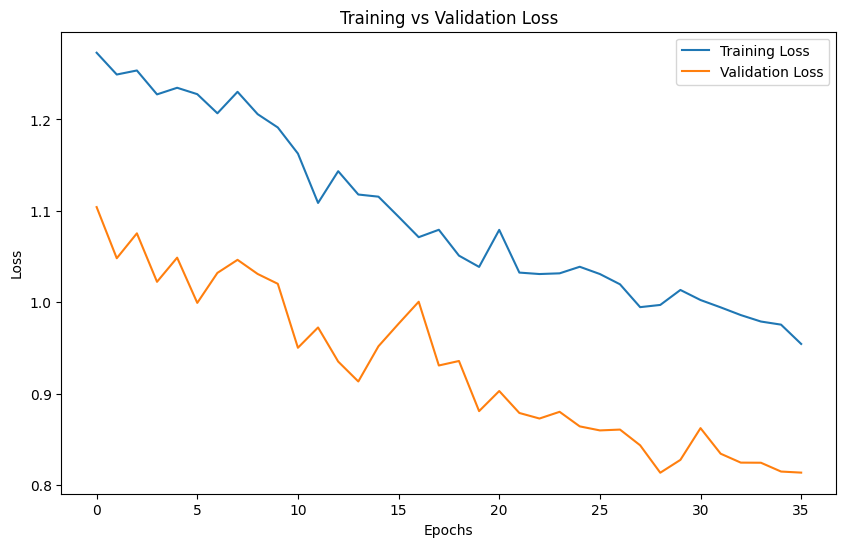

In [34]:
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=100)

# Plot the loss curves
plot_loss_curves(train_losses, val_losses)


In [35]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
import numpy as np

def evaluate_model(model, dataloader, class_names):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # Metrics
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\nAccuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    # Confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # AUC-ROC
    try:
        if len(class_names) == 2:
            auc = roc_auc_score(all_labels, all_probs[:, 1])
        else:
            auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
        print(f"AUC-ROC:   {auc:.4f}")
    except:
        print("⚠️ Could not compute AUC-ROC (check labels or probabilities)")

    return acc, precision, recall, f1


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Accuracy:  0.7231
Precision: 0.7056
Recall:    0.7231
F1-score:  0.7094


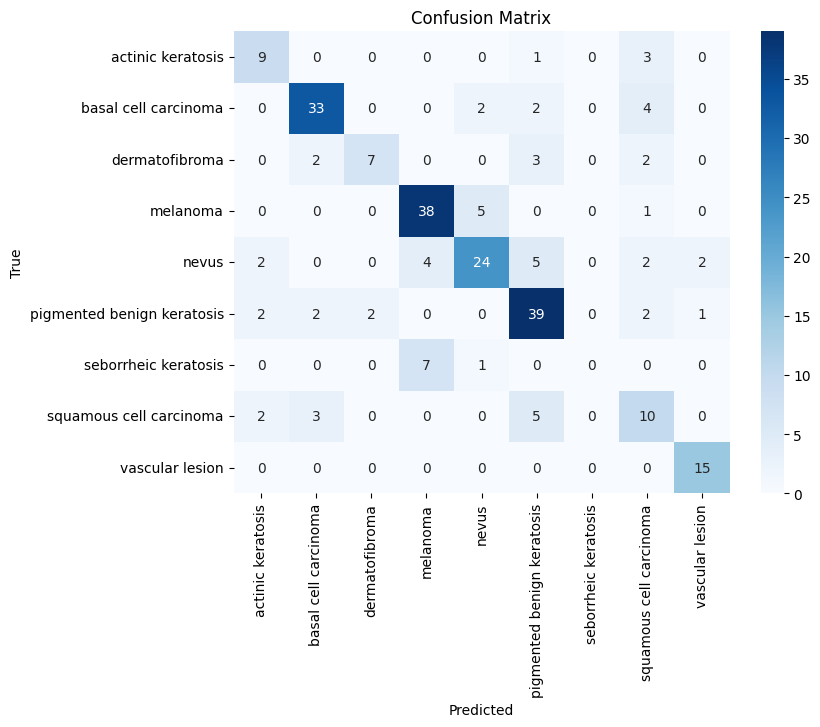

AUC-ROC:   0.9592


(0.7231404958677686, 0.7056034497445359, 0.7231404958677686, 0.709447368247004)

In [36]:
evaluate_model(model, test_loader, class_names)


In [37]:
!pip install torchsummary
c()
from torchsummary import summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
            Conv2d-4         [-1, 64, 224, 224]          36,928
       BatchNorm2d-5         [-1, 64, 224, 224]             128
              ReLU-6         [-1, 64, 224, 224]               0
         MaxPool2d-7         [-1, 64, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]          73,856
       BatchNorm2d-9        [-1, 128, 112, 112]             256
             ReLU-10        [-1, 128, 112, 112]               0
           Conv2d-11        [-1, 128, 112, 112]         147,584
      BatchNorm2d-12        [-1, 128, 112, 112]             256
             ReLU-13        [-1, 128, 112, 112]               0
        MaxPool2d-14          [-1, 128,

In [40]:
torch.save(model, 'model.pth')  # Saves the entire model


In [41]:
model.eval()

SkinDiseaseCNNDeeper(
  (conv_block): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256, kernel_size=(3, 3), stride=

In [ ]:
model = torch.load('model.pth')